Training Standard VAE (Beta = 1.0)...
Training Disentangled Beta-VAE (Beta = 6.0)...


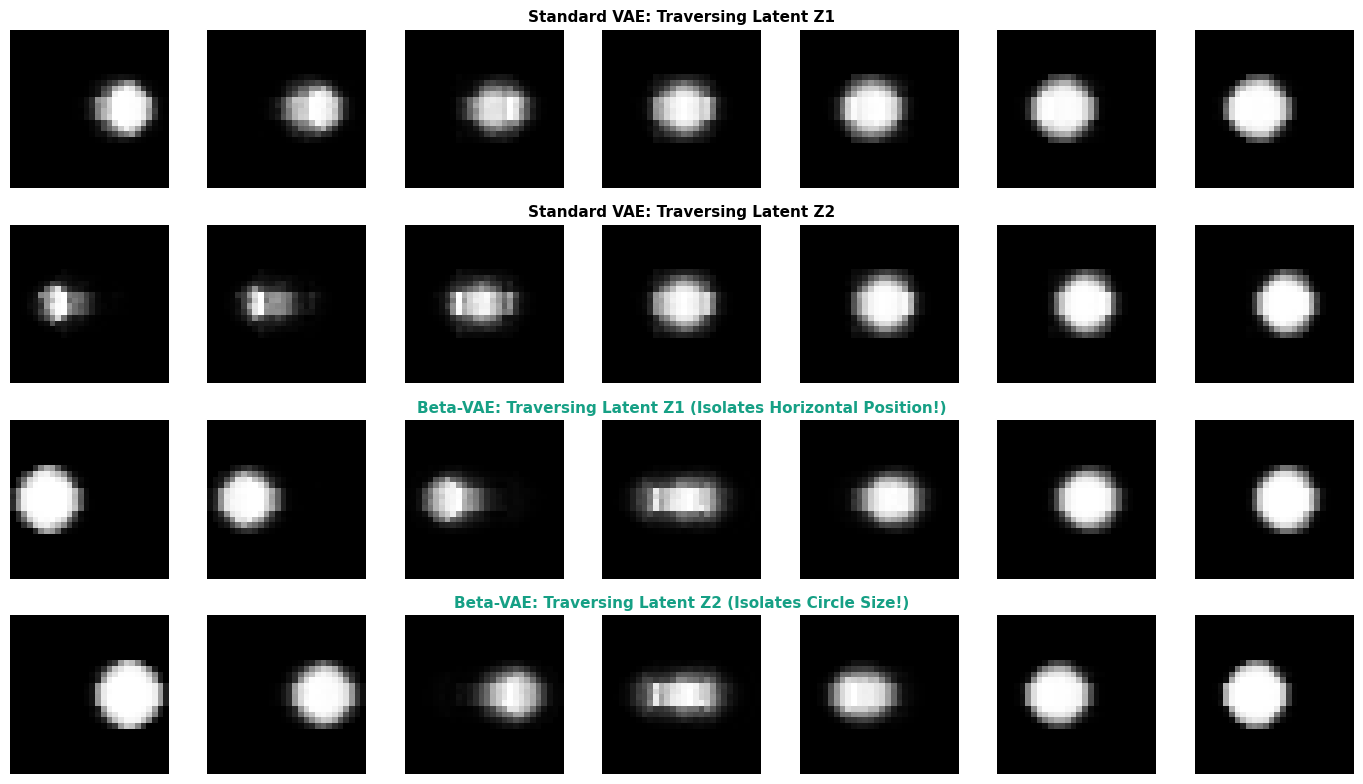

In [ ]:
# ==========================================
# Setup
# ==========================================

import os  # system tools
import warnings  # silence warnings
import numpy as np  # fast math
import torch  # deep learning
import torch.nn as nn  # neural layers
import torch.nn.functional as F  # activation functions
import torch.optim as optim  # model trainers
from PIL import Image, ImageDraw  # draw shapes
import matplotlib.pyplot as plt  # plot graphs
import seaborn as sns  # plot styling

warnings.filterwarnings('ignore')  # hide warnings

SEED = 42  # standard seed
torch.manual_seed(SEED)  # seed pytorch
np.random.seed(SEED)  # seed numpy

# ==========================================
# 1. Generate Synthetic Circle Dataset
# ==========================================

# generate_circles_data: Creates synthetic circle images with two independent factors (x-position, radius) - each sample has 784 pixels (28x28 flattened), used to test disentanglement.
def generate_circles_data(num_samples=400):
    images = []  # holding list
    latents = []  # ground-truth latent list [x_position, radius]

    for _ in range(num_samples):
        img = Image.new('L', (28, 28), color=0)  # black 28x28 canvas
        draw = ImageDraw.Draw(img)  # draw tool

        # Vary two independent physical factors
        x_pos = np.random.uniform(6, 22)  # vary horizontal position
        radius = np.random.uniform(3, 6)  # vary circle radius size

        # Draw circle on canvas
        draw.ellipse([x_pos - radius, 14 - radius, x_pos + radius, 14 + radius], fill=255)

        arr = np.array(img, dtype=np.float32) / 255.0  # normalize pixels [2]
        images.append(arr.flatten())  # flatten to 784-D vector
        latents.append([x_pos, radius])  # save factors

    return np.array(images), np.array(latents)  # return datasets

# Generate data
X_train_raw, latents_raw = generate_circles_data()  # execute data generator

# ==========================================
# 2. Beta-VAE Model Architecture
# ==========================================

# BetaVAE: VAE with encoder (784→128→64 → mu/logvar) and decoder (2→64→128→784). Latent dim=2, sigmoid output for pixel probabilities.
class BetaVAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.latent_dim = latent_dim  # compressed latent dimensions

        # Encoder Network (Inference)
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),  # layer 1
            nn.ReLU(),  # activate 1
            nn.Linear(128, 64),  # layer 2
            nn.ReLU(),  # activate 2
        )
        self.fc_mu = nn.Linear(64, latent_dim)  # mu parameters (means)
        self.fc_logvar = nn.Linear(64, latent_dim)  # log-variance parameters

        # Decoder Network (Generator)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),  # layer 1
            nn.ReLU(),  # activate 1
            nn.Linear(64, 128),  # layer 2
            nn.ReLU(),  # activate 2
            nn.Linear(128, 784),  # output layer
            nn.Sigmoid()  # squash output pixels to [2]
        )

    def reparameterize(self, mu, logvar):
        # Reparameterization trick: sample Gaussian perturbations
        std = torch.exp(0.5 * logvar)  # calculate standard deviation
        eps = torch.randn_like(std)  # sample epsilon
        return mu + eps * std  # scale perturbation

    def forward(self, x):
        h = self.encoder(x)  # compress input
        mu = self.fc_mu(h)  # calculate mu
        logvar = self.fc_logvar(h)  # calculate logvar
        z = self.reparameterize(mu, logvar)  # sample latent variable z
        recon_x = self.decoder(z)  # reconstruct image from z
        return recon_x, mu, logvar  # return variables

# ==========================================
# 3. Disentangled Beta-VAE Loss Function
# ==========================================

def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    # Reconstruction loss (pixel-level binary cross-entropy)
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # Kullback-Leibler (KL) Divergence loss against a Gaussian prior
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Scale KLD term by beta to control disentanglement pressure
    total_loss = recon_loss + beta * kld_loss
    return total_loss, recon_loss, kld_loss  # return losses

# ==========================================
# 4. Training Pipeline (Standard vs Beta)
# ==========================================

def train_model(model, X, epochs=120, lr=0.003, beta=1.0):
    optimizer = optim.Adam(model.parameters(), lr=lr)  # setup optimizer
    X_t = torch.FloatTensor(X)  # convert inputs to tensors

    for epoch in range(epochs):
        model.train()  # set training state
        recon, mu, logvar = model(X_t)  # forward pass

        # Calculate losses (normalized across the batch size)
        loss, r_loss, k_loss = vae_loss(recon, X_t, mu, logvar, beta)
        loss = loss / len(X)  # batch mean loss

        optimizer.zero_grad()  # clean gradients
        loss.backward()  # backpropagation
        optimizer.step()  # update weights

    return model  # return trained model

# Train Standard VAE (Beta = 1.0)
print("Training Standard VAE (Beta = 1.0)...")  # status log
vae_standard = BetaVAE(latent_dim=2)  # init baseline VAE
vae_standard = train_model(vae_standard, X_train_raw, beta=1.0)  # train baseline

# Train Disentangled Beta-VAE (Beta = 6.0)
print("Training Disentangled Beta-VAE (Beta = 6.0)...")  # status log
vae_beta = BetaVAE(latent_dim=2)  # init disentangled BNN VAE
vae_beta = train_model(vae_beta, X_train_raw, beta=6.0)  # train disentangled model

# ==========================================
# 5. Visualizing Latent Traversals
# ==========================================

def generate_traversals_grid(model, name):
    model.eval()  # freeze batchnorm and dropouts
    grid = []  # save image frames

    # Let's traverse Latent Dimension 1 (fixing Dimension 2 at 0)
    sweep = np.linspace(-2.0, 2.0, 7)  # sweep range [-2, +2]

    # Row 1: Traverse Latent Z1
    for val in sweep:
        z = torch.FloatTensor([[val, 0.0]])  # set latent vector
        with torch.no_grad():
            recon = model.decoder(z).numpy().reshape(28, 28)  # generate image
        grid.append(recon)  # save frame

    # Row 2: Traverse Latent Z2
    for val in sweep:
        z = torch.FloatTensor([[0.0, val]])  # set latent vector
        with torch.no_grad():
            recon = model.decoder(z).numpy().reshape(28, 28)  # generate image
        grid.append(recon)  # save frame

    return np.array(grid)  # return traversal frames

# Generate grids
grid_std = generate_traversals_grid(vae_standard, "Standard VAE")  # baseline grid
grid_beta = generate_traversals_grid(vae_beta, "Beta-VAE")  # proposed grid

# Plot traversals side-by-side
fig, axes = plt.subplots(4, 7, figsize=(14, 8))  # 4 rows, 7 columns canvas
sns.set_theme(style="white")  # set styling

# Plot Standard VAE Traversals
for i in range(7):
    axes[0, i].imshow(grid_std[i], cmap='gray')  # Z1 traversal
    axes[0, i].axis('off')
    if i == 3: axes[0, i].set_title("Standard VAE: Traversing Latent Z1", fontsize=11, fontweight='bold')

    axes[1, i].imshow(grid_std[i+7], cmap='gray')  # Z2 traversal
    axes[1, i].axis('off')
    if i == 3: axes[1, i].set_title("Standard VAE: Traversing Latent Z2", fontsize=11, fontweight='bold')

# Plot Beta-VAE Traversals
for i in range(7):
    axes[2, i].imshow(grid_beta[i], cmap='gray')  # Z1 traversal
    axes[2, i].axis('off')
    if i == 3: axes[2, i].set_title("Beta-VAE: Traversing Latent Z1 (Isolates Horizontal Position!)", fontsize=11, fontweight='bold', color='#16a085')

    axes[3, i].imshow(grid_beta[i+7], cmap='gray')  # Z2 traversal
    axes[3, i].axis('off')
    if i == 3: axes[3, i].set_title("Beta-VAE: Traversing Latent Z2 (Isolates Circle Size!)", fontsize=11, fontweight='bold', color='#16a085')

plt.tight_layout()  # fit layouts
plt.show()  # render plot